# 🤟 Sign Language Tutor - Asistente de Lenguaje de Señas

---

**Autor:** César Adrián Delgado Díaz  
**LinkedIn:** [linkedin.com/in/cesar-delgado-diaz](https://www.linkedin.com/in/cesar-delgado-diaz)  
**GitHub:** [github.com/cesar530](https://github.com/cesar530)  
**Fecha:** Enero 2026  
**Licencia:** MIT

---

## 📋 Descripción del Proyecto

Sistema inteligente de reconocimiento y tutoría de **lenguaje de señas Mexicano (LSM)** utilizando:

- **Visión por Computadora** (MediaPipe + OpenCV)
- **Machine Learning** (Scikit-learn + TensorFlow)
- **Interacción en Tiempo Real** con retroalimentación inmediata

### 🎯 Objetivos

1. ✅ **Reconocer** lenguaje de señas desde cámara en tiempo real
2. ✅ **Tutorizar** con lecciones estructuradas y retroalimentación
3. ✅ **Practicar** mediante roleplay conversacional con agente IA

### 🛠️ Stack Tecnológico

| Tecnología | Versión | Propósito |
|------------|---------|----------|
| Python | 3.12.8 | Lenguaje principal |
| MediaPipe | 0.10.9 | Detección de manos |
| OpenCV | 4.9.0 | Procesamiento de video |
| Scikit-learn | 1.4.0 | Clasificación ML |
| TensorFlow | 2.15.0 | Deep Learning |
| NumPy | 1.26.3 | Operaciones numéricas |

---

## 📦 1. Instalación y Setup

### 1.1 Instalación de Dependencias

In [1]:
# Instalar dependencias (ejecutar solo una vez)
# !pip install -r requirements.txt

### 1.2 Importaciones

In [ ]:
# Importaciones estándar
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Importaciones de Computer Vision
import cv2
import mediapipe as mp

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"OpenCV: {cv2.__version__}")
print(f"MediaPipe: {mp.__version__}")
print(f"NumPy: {np.__version__}")

✅ Librerías importadas correctamente
OpenCV: 4.13.0
MediaPipe: 0.10.31
NumPy: 2.4.1


### 1.3 Importar Módulos del Proyecto

In [3]:
# Importar módulos locales
from config import (
    CAMERA, MEDIAPIPE, DETECTION, UI, TUTOR,
    ALL_SIGNS, NUM_CLASSES, PROJECT_ROOT, MODELS_DIR,
    get_sign_name, get_class_id
)

from utils import (
    HandLandmarks, HandType, DetectionResult,
    preprocess_frame, extract_landmarks_from_results,
    create_feature_vector, load_lessons
)

from sign_language_tutor import (
    HandDetector, SignClassifier, LessonManager,
    ConversationAgent, SignLanguageTutor
)

print("✅ Módulos del proyecto importados")
print(f"📁 Directorio del proyecto: {PROJECT_ROOT}")
print(f"🎓 Total de señas soportadas: {NUM_CLASSES}")

✅ Módulos del proyecto importados
📁 Directorio del proyecto: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\15_Tutor_Lenguaje_Señas
🎓 Total de señas soportadas: 65


---

## 🔍 2. Exploración del Sistema

### 2.1 Configuración del Proyecto

In [4]:
# Visualizar configuración principal
config_info = {
    "Cámara": {
        "Resolución": f"{CAMERA.width}x{CAMERA.height}",
        "FPS": CAMERA.fps,
        "Flip Horizontal": CAMERA.flip_horizontal
    },
    "MediaPipe": {
        "Max Manos": MEDIAPIPE.max_num_hands,
        "Confianza Detección": MEDIAPIPE.min_detection_confidence,
        "Confianza Tracking": MEDIAPIPE.min_tracking_confidence
    },
    "Detección": {
        "Umbral Confianza": DETECTION.confidence_threshold,
        "Suavizado": DETECTION.prediction_smoothing,
        "Ventana Suavizado": DETECTION.smoothing_window
    },
    "Tutoría": {
        "Delay Feedback": f"{TUTOR.feedback_delay}s",
        "Precisión Mínima": f"{TUTOR.min_accuracy_to_pass*100}%",
        "Repeticiones por Seña": TUTOR.repetitions_per_sign
    }
}

pd.DataFrame([
    {"Categoría": cat, "Parámetro": param, "Valor": val}
    for cat, params in config_info.items()
    for param, val in params.items()
])

,Categoría,Parámetro,Valor
0,Cámara,Resolución,640x480
1,Cámara,FPS,30
2,Cámara,Flip Horizontal,True
3,MediaPipe,Max Manos,2
4,MediaPipe,Confianza Detección,0.7
5,MediaPipe,Confianza Tracking,0.5
6,Detección,Umbral Confianza,0.7
7,Detección,Suavizado,True
8,Detección,Ventana Suavizado,5
9,Tutoría,Delay Feedback,1.5s


### 2.2 Señas Disponibles

📚 Señas del Alfabeto ASL (26 letras):
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'Ñ', 'O', 'P', 'Q', 'R', 'RR', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

🔢 Números ASL (0-9):
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '100', '1000']

💬 Palabras/Frases Comunes:
['HOLA', 'ADIOS', 'GRACIAS', 'POR_FAVOR', 'SI', 'NO', 'AYUDA', 'PERDON', 'AMOR', 'AMIGO', 'FAMILIA', 'MAMA', 'PAPA', 'HERMANO', 'AGUA', 'COMIDA', 'CASA', 'TRABAJO', 'ESCUELA', 'BUENOS_DIAS', 'BUENAS_NOCHES', 'COMO_ESTAS', 'MUCHO_GUSTO', 'ME_LLAMO']


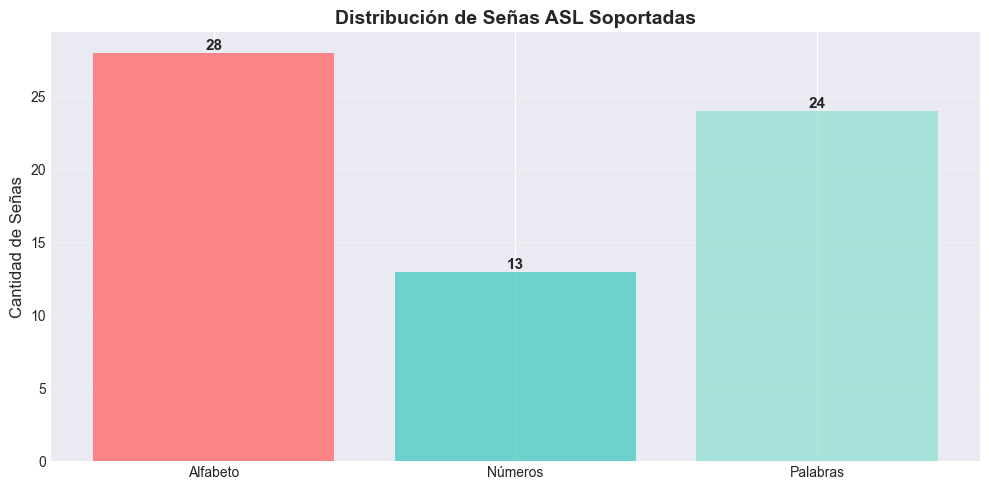


✅ Total: 65 señas soportadas


In [5]:
# Visualizar todas las señas disponibles
from config import ASL_ALPHABET, ASL_NUMBERS, ASL_WORDS

print("📚 Señas del Alfabeto ASL (26 letras):")
print(list(ASL_ALPHABET.values()))

print("\n🔢 Números ASL (0-9):")
print(list(ASL_NUMBERS.values()))

print("\n💬 Palabras/Frases Comunes:")
print(list(ASL_WORDS.values()))

# Gráfico de distribución
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Alfabeto', 'Números', 'Palabras']
counts = [len(ASL_ALPHABET), len(ASL_NUMBERS), len(ASL_WORDS)]
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

bars = ax.bar(categories, counts, color=colors, alpha=0.8)
ax.set_ylabel('Cantidad de Señas', fontsize=12)
ax.set_title('Distribución de Señas ASL Soportadas', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Agregar valores encima de las barras
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ Total: {NUM_CLASSES} señas soportadas")

### 2.3 Curriculum de Lecciones

In [6]:
# Cargar y visualizar estructura de lecciones
lessons_data = load_lessons("lessons.json")

lessons_df_data = []
for level in lessons_data.get("levels", []):
    for lesson in level.get("lessons", []):
        lessons_df_data.append({
            "Nivel": level["name"],
            "ID": lesson["id"],
            "Título": lesson["title"],
            "Dificultad": lesson.get("difficulty", "N/A"),
            "Duración (min)": lesson.get("duration_minutes", 0),
            "Señas": len(lesson.get("signs", [])),
        })

lessons_df = pd.DataFrame(lessons_df_data)
print("\n📖 Curriculum de Lecciones:")
print(lessons_df.to_string(index=False))

# Estadísticas
print(f"\n📊 Estadísticas del Curriculum:")
print(f"  • Total de lecciones: {len(lessons_df)}")
print(f"  • Duración total: {lessons_df['Duración (min)'].sum()} minutos")
print(f"  • Promedio por lección: {lessons_df['Duración (min)'].mean():.1f} minutos")
print(f"  • Total de señas únicas: {lessons_df['Señas'].sum()}")


📖 Curriculum de Lecciones:
           Nivel                          ID                      Título   Dificultad  Duración (min)  Señas
     Fundamentos           L1_01_alphabet_az          Alfabeto ASL (A-M)     beginner              20     13
     Fundamentos           L1_02_alphabet_nz          Alfabeto ASL (N-Z)     beginner              20     13
     Fundamentos               L1_03_numbers               Números (0-9)     beginner              15     10
Palabras Básicas             L2_01_greetings                     Saludos     beginner              15      4
Palabras Básicas             L2_02_responses          Respuestas Básicas     beginner              15      4
Palabras Básicas              L2_03_emotions                   Emociones intermediate              20      2
  Frases Simples         L3_01_introductions              Presentaciones intermediate              25      2
  Frases Simples             L3_02_questions           Preguntas Básicas intermediate              2

---

## 🧪 3. Demostración de Componentes

### 3.1 Test del Detector de Manos

2026-01-23 13:38:35,771 - sign_language_tutor - INFO - Modelo cargado como bytes (7819105 bytes)
2026-01-23 13:38:36,077 - sign_language_tutor - INFO - HandDetector (Tasks API) inicializado correctamente


✅ HandDetector inicializado
Manos detectadas: 1
  Mano 1: Left (confianza: 0.95)
    Landmarks shape: (21, 3)


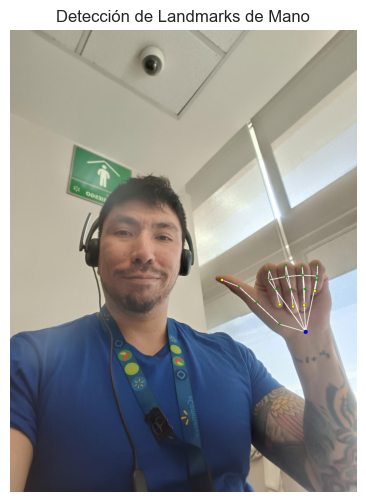

In [7]:
# Inicializar detector
detector = HandDetector()
print("✅ HandDetector inicializado")

# Test con una imagen de prueba (si existe)
# Si no existe, se saltará esta sección
test_image_path = PROJECT_ROOT / "assets" / "test_hand.jpg"

if test_image_path.exists():
    # Usar numpy para leer la imagen (evita problemas con rutas con espacios)
    # OpenCV tiene problemas con rutas que contienen espacios en Windows
    with open(test_image_path, 'rb') as f:
        img_array = np.frombuffer(f.read(), dtype=np.uint8)
    test_img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    
    if test_img is None:
        print("❌ Error: No se pudo decodificar la imagen. Verifica que sea un JPG válido.")
    else:
        hands, results = detector.detect(test_img)
        
        print(f"Manos detectadas: {len(hands)}")
        
        if hands:
            for i, hand in enumerate(hands):
                print(f"  Mano {i+1}: {hand.hand_type.value} (confianza: {hand.confidence:.2f})")
                print(f"    Landmarks shape: {hand.landmarks.shape}")
        
        # Visualizar
        test_img_annotated = detector.draw_landmarks(test_img.copy(), results)
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(test_img_annotated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Detección de Landmarks de Mano')
        plt.show()
else:
    print("ℹ️ No se encontró imagen de prueba. Usa la cámara para probar en vivo.")
    print(f"   Ruta esperada: {test_image_path}")

### 3.2 Test de Extracción de Características

🧪 Test de Feature Engineering:
Landmarks originales: (21, 3)
Landmarks normalizados: (21, 3)
Vector de características: (93,)
  - Landmarks planos: 63 features (21 puntos × 3 coords)
  - Ángulos entre dedos: 15 features
  - Distancias entre puntas: 15 features
  - Total: 93 features


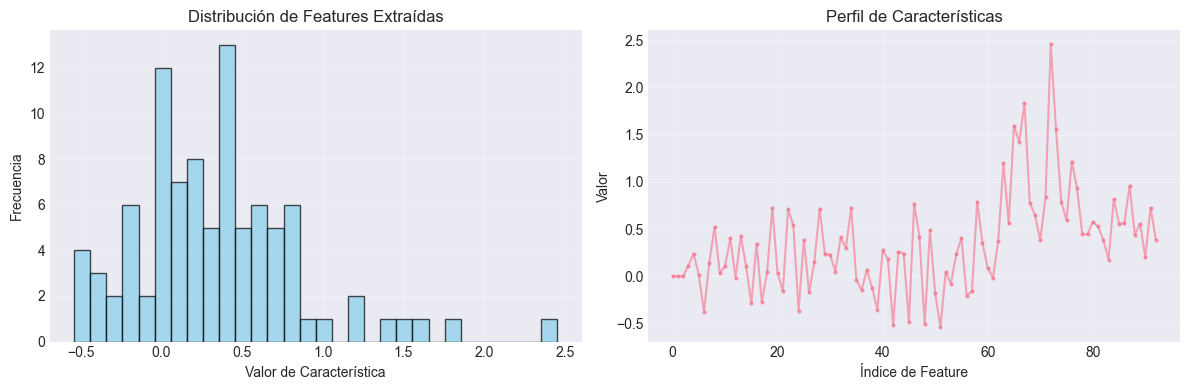

In [8]:
# Simular landmarks de mano para test
test_landmarks = np.random.rand(21, 3)  # 21 puntos, 3 coordenadas
test_hand = HandLandmarks(
    landmarks=test_landmarks,
    hand_type=HandType.RIGHT,
    confidence=0.95
)

print("🧪 Test de Feature Engineering:")
print(f"Landmarks originales: {test_hand.landmarks.shape}")

# Normalizar
normalized = test_hand.normalize()
print(f"Landmarks normalizados: {normalized.landmarks.shape}")

# Extraer vector de características completo
features = create_feature_vector(test_hand)
print(f"Vector de características: {features.shape}")
print(f"  - Landmarks planos: 63 features (21 puntos × 3 coords)")
print(f"  - Ángulos entre dedos: 15 features")
print(f"  - Distancias entre puntas: 15 features")
print(f"  - Total: {len(features)} features")

# Visualizar distribución de características
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(features, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Valor de Característica')
plt.ylabel('Frecuencia')
plt.title('Distribución de Features Extraídas')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(features, marker='o', linestyle='-', markersize=2, alpha=0.6)
plt.xlabel('Índice de Feature')
plt.ylabel('Valor')
plt.title('Perfil de Características')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Test del Clasificador

In [9]:
# Inicializar clasificador
classifier = SignClassifier()
print("✅ SignClassifier inicializado")
print(f"Modo: {'Modelo entrenado' if classifier.is_trained else 'Basado en reglas (demo)'}")

# Probar predicción
detection = classifier.predict(test_hand)
print(f"\n🎯 Predicción de prueba:")
print(f"  Seña: {detection.sign}")
print(f"  Confianza: {detection.confidence:.2%}")
print(f"  Timestamp: {detection.timestamp}")

# Test de suavizado de predicciones
print("\n📊 Test de suavizado de predicciones:")
test_predictions = ["A", "A", "B", "A", "A", "A"]
test_confidences = [0.9, 0.85, 0.6, 0.88, 0.92, 0.87]

for pred, conf in zip(test_predictions, test_confidences):
    test_hand_temp = HandLandmarks(
        landmarks=np.random.rand(21, 3),
        hand_type=HandType.RIGHT,
        confidence=conf
    )
    result = classifier.predict(test_hand_temp)

print(f"Predicciones en buffer: {list(classifier.prediction_buffer)}")
print("✅ El suavizado ayuda a eliminar detecciones esporádicas incorrectas")

2026-01-23 13:38:36,710 - sign_language_tutor - INFO - Usando clasificador basado en reglas (sin modelo entrenado)


✅ SignClassifier inicializado
Modo: Basado en reglas (demo)

🎯 Predicción de prueba:
  Seña: UNKNOWN
  Confianza: 50.00%
  Timestamp: 2026-01-23 13:38:36.714152

📊 Test de suavizado de predicciones:
Predicciones en buffer: ['5', 'UNKNOWN', 'UNKNOWN', 'V', 'UNKNOWN']
✅ El suavizado ayuda a eliminar detecciones esporádicas incorrectas


### 3.3 Test del Clasificador con Imagen Real

🖼️ Test del Clasificador con Imagen Real

📍 Información de la mano detectada:
   Tipo: Left
   Confianza detección: 95.27%
   Landmarks shape: (21, 3)

🎯 Predicción con landmarks REALES:
   Seña detectada: A
   Confianza: 50.00%
   Timestamp: 2026-01-23 13:38:36.753691

📊 Comparación:
   Tipo                      Seña            Confianza      
   -------------------------------------------------------
   Landmarks REALES          A               50.00%
   Landmarks aleatorios      UNKNOWN         50.00%

🔢 Características extraídas de imagen real:
   Total features: 93
   Min valor: -0.8758
   Max valor: 3.0931
   Media: 0.2760
   Std: 0.9670


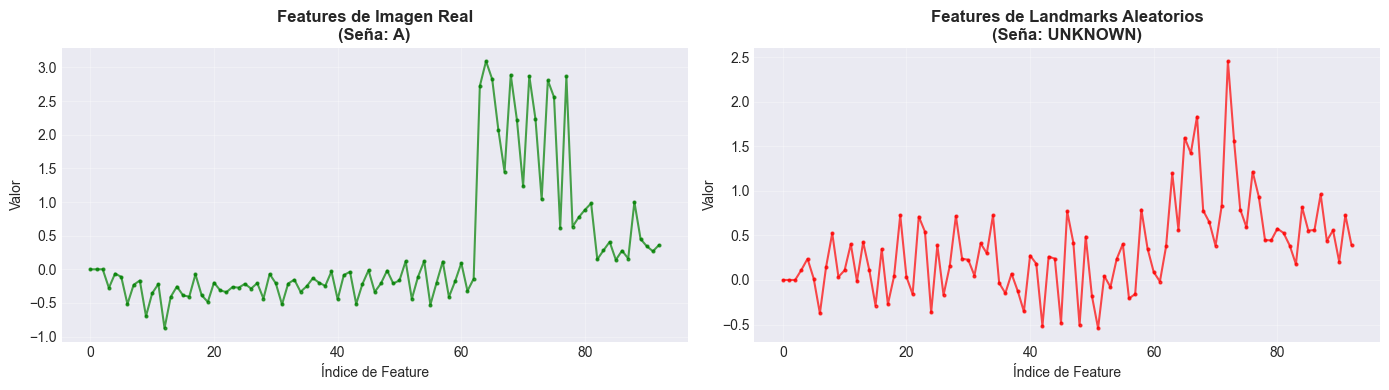


✅ Las características de landmarks reales tienen patrones más estructurados
   mientras que las aleatorias son ruido uniforme.


In [10]:
# Usar los landmarks detectados de la imagen test_hand.jpg

print("🖼️ Test del Clasificador con Imagen Real")
print("=" * 60)

if test_image_path.exists() and 'hands' in dir() and len(hands) > 0:
    # Usar la primera mano detectada de la imagen real
    real_hand = hands[0]
    
    print(f"\n📍 Información de la mano detectada:")
    print(f"   Tipo: {real_hand.hand_type.value}")
    print(f"   Confianza detección: {real_hand.confidence:.2%}")
    print(f"   Landmarks shape: {real_hand.landmarks.shape}")
    
    # Reiniciar el buffer del clasificador para una predicción limpia
    classifier.prediction_buffer.clear()
    
    # Hacer predicción con los landmarks reales
    real_detection = classifier.predict(real_hand)
    
    print(f"\n🎯 Predicción con landmarks REALES:")
    print(f"   Seña detectada: {real_detection.sign}")
    print(f"   Confianza: {real_detection.confidence:.2%}")
    print(f"   Timestamp: {real_detection.timestamp}")
    
    # Comparar con predicción de landmarks aleatorios
    print(f"\n📊 Comparación:")
    print(f"   {'Tipo':<25} {'Seña':<15} {'Confianza':<15}")
    print(f"   {'-'*55}")
    print(f"   {'Landmarks REALES':<25} {real_detection.sign:<15} {real_detection.confidence:.2%}")
    print(f"   {'Landmarks aleatorios':<25} {detection.sign:<15} {detection.confidence:.2%}")
    
    # Extraer características de la mano real
    real_features = create_feature_vector(real_hand)
    print(f"\n🔢 Características extraídas de imagen real:")
    print(f"   Total features: {len(real_features)}")
    print(f"   Min valor: {real_features.min():.4f}")
    print(f"   Max valor: {real_features.max():.4f}")
    print(f"   Media: {real_features.mean():.4f}")
    print(f"   Std: {real_features.std():.4f}")
    
    # Visualizar comparación de características
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Features de imagen real
    axes[0].plot(real_features, marker='o', linestyle='-', markersize=2, alpha=0.7, color='green')
    axes[0].set_xlabel('Índice de Feature')
    axes[0].set_ylabel('Valor')
    axes[0].set_title(f'Features de Imagen Real\n(Seña: {real_detection.sign})', fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Features de landmarks aleatorios
    axes[1].plot(features, marker='o', linestyle='-', markersize=2, alpha=0.7, color='red')
    axes[1].set_xlabel('Índice de Feature')
    axes[1].set_ylabel('Valor')
    axes[1].set_title(f'Features de Landmarks Aleatorios\n(Seña: {detection.sign})', fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Las características de landmarks reales tienen patrones más estructurados")
    print("   mientras que las aleatorias son ruido uniforme.")
else:
    print("⚠️ No hay manos detectadas de la imagen real.")
    print("   Asegúrate de ejecutar la celda 15 primero con una imagen válida.")
    print(f"   Ruta esperada: {test_image_path}")

---

## 🎓 4. Sistema de Lecciones

### 4.1 Selector de Idioma y Gestor de Lecciones

El sistema soporta **dos idiomas de señas**:

| Idioma | Código | Descripción |
|--------|--------|-------------|
| 🇺🇸 **ASL** | `SignLanguage.ASL` | American Sign Language (26 letras) |
| 🇲🇽 **LSM** | `SignLanguage.LSM` | Lengua de Señas Mexicana (28 letras: incluye Ñ y RR) |

**Para cambiar de idioma:** Modifica la variable `idioma_seleccionado` en la celda de abajo.

In [11]:
# Importar el sistema de selección de idioma
from config import SignLanguage, set_sign_language, get_sign_language_info

# =============================================================================
# 🌐 SELECTOR DE IDIOMA DE SEÑAS
# =============================================================================
# Cambia la variable 'idioma_seleccionado' para elegir entre:
#   - SignLanguage.ASL  → American Sign Language (Inglés)
#   - SignLanguage.LSM  → Lengua de Señas Mexicana (Español)

idioma_seleccionado = SignLanguage.LSM  # ← CAMBIA AQUÍ EL IDIOMA

# Aplicar el idioma seleccionado
set_sign_language(idioma_seleccionado)
info = get_sign_language_info()

print("=" * 60)
print(f"🌐 IDIOMA DE SEÑAS ACTIVO: {info['name']}")
print("=" * 60)
print(f"   Código: {info['code']}")
print(f"   Alfabeto: {info['alphabet_count']} señas")
print(f"   Números: {info['numbers_count']} señas")
print(f"   Palabras: {info['words_count']} señas")
print(f"   Total: {info['total']} señas")
print("=" * 60)

# Inicializar gestor de lecciones con el idioma seleccionado
lesson_manager = LessonManager()
print(f"\n✅ LessonManager inicializado para {info['code']}")

# Obtener lecciones disponibles
available_lessons = lesson_manager.get_available_lessons()

print(f"\n📚 {len(available_lessons)} lecciones disponibles:\n")
for i, lesson in enumerate(available_lessons, 1):
    print(f"{i:2d}. [{lesson['difficulty']:12s}] {lesson['title']}")
    print(f"    Nivel: {lesson['level']} | Señas: {lesson['signs_count']}")
    print()

2026-01-23 13:38:37,014 - sign_language_tutor - INFO - LessonManager inicializado con 16 lecciones


🌐 IDIOMA DE SEÑAS ACTIVO: Lengua de Señas Mexicana
   Código: LSM
   Alfabeto: 28 señas
   Números: 13 señas
   Palabras: 24 señas
   Total: 65 señas

✅ LessonManager inicializado para LSM

📚 16 lecciones disponibles:

 1. [principiante] Alfabeto LSM (A-M)
    Nivel: Fundamentos LSM | Señas: 13

 2. [principiante] Alfabeto LSM (N-Z) con Ñ
    Nivel: Fundamentos LSM | Señas: 15

 3. [principiante] Números (0-10)
    Nivel: Fundamentos LSM | Señas: 11

 4. [principiante] Números Grandes (100, 1000)
    Nivel: Fundamentos LSM | Señas: 3

 5. [principiante] Saludos y Despedidas
    Nivel: Palabras Básicas LSM | Señas: 4

 6. [principiante] Expresiones de Cortesía
    Nivel: Palabras Básicas LSM | Señas: 3

 7. [principiante] Respuestas Básicas
    Nivel: Palabras Básicas LSM | Señas: 3

 8. [principiante] La Familia
    Nivel: Palabras Básicas LSM | Señas: 4

 9. [intermedio  ] Emociones y Sentimientos
    Nivel: Palabras Básicas LSM | Señas: 2

10. [intermedio  ] Necesidades Básicas
    N

### 4.2 Simulación de una Lección

In [12]:
# Iniciar lección de ejemplo
lesson_id = "L1_01_alfabeto_am"
lesson_manager.start_lesson(lesson_id)

print(f"🎯 Lección iniciada: {lesson_manager.current_lesson['title']}")
print(f"Descripción: {lesson_manager.current_lesson['description']}")
print(f"\nSeñas a aprender: {lesson_manager.current_lesson['signs']}")
print(f"\nObjetivos:")
for obj in lesson_manager.current_lesson['objectives']:
    print(f"  • {obj}")

# Simular práctica de señas
print("\n" + "="*60)
print("SIMULACIÓN DE PRÁCTICA")
print("="*60)

simulated_attempts = [
    ("0", 0.85, "Correcto"),
    ("1", 0.65, "Baja confianza"),
    ("1", 0.88, "Correcto"),
    ("2", 0.92, "Correcto"),
    ("5", 0.70, "Incorrecto (target: 3)"),
    ("3", 0.90, "Correcto"),
]

for detected, confidence, note in simulated_attempts:
    target = lesson_manager.get_current_target()
    if not target:
        break
    
    result = lesson_manager.check_sign(detected, confidence)
    
    status = "✅" if result['is_correct'] else "❌"
    print(f"\n{status} Intento #{result['attempts']}")
    print(f"   Target: {result['target']} | Detected: {result['detected']} ({confidence:.0%})")
    print(f"   {result['feedback']}")
    print(f"   Nota: {note}")

# Mostrar progreso final
progress = lesson_manager.get_progress()
print("\n" + "="*60)
print("PROGRESO FINAL")
print("="*60)
print(f"Lección: {progress['lesson_title']}")
print(f"Progreso: {progress['current_index']}/{progress['total_signs']} señas completadas")
print(f"Señas correctas: {progress['completed']}")
print(f"Score: {progress['score']} puntos")
print(f"Precisión: {progress['accuracy']:.1f}%")
print(f"Total de intentos: {progress['attempts']}")

2026-01-23 13:38:37,047 - sign_language_tutor - INFO - Lección iniciada: Alfabeto LSM (A-M)


🎯 Lección iniciada: Alfabeto LSM (A-M)
Descripción: Aprende las primeras letras del alfabeto en LSM

Señas a aprender: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']

Objetivos:
  • Reconocer la posición de mano para cada letra
  • Ejecutar cada seña con claridad
  • Deletrear palabras simples en español

SIMULACIÓN DE PRÁCTICA

❌ Intento #1
   Target: A | Detected: 0 (85%)
   Sigue intentando. Muestra la seña 'A'. 💪
   Nota: Correcto

❌ Intento #2
   Target: A | Detected: 1 (65%)
   Sigue intentando. Muestra la seña 'A'. 💪
   Nota: Baja confianza

❌ Intento #3
   Target: A | Detected: 1 (88%)
   Sigue intentando. Muestra la seña 'A'. 💪
   Nota: Correcto

❌ Intento #4
   Target: A | Detected: 2 (92%)
   Sigue intentando. Muestra la seña 'A'. 💪
   Nota: Correcto

❌ Intento #5
   Target: A | Detected: 5 (70%)
   Sigue intentando. Muestra la seña 'A'. 💪
   Nota: Incorrecto (target: 3)

❌ Intento #6
   Target: A | Detected: 3 (90%)
   Sigue intentando. Muestra la seña 'A

---

## 💬 5. Agente Conversacional

### 5.1 Inicialización del Agente

In [13]:
# Inicializar agente conversacional (usa el idioma seleccionado en la celda 23)
agent = ConversationAgent()

# Obtener información del idioma del agente
agent_lang = agent.get_language_info()

print("=" * 60)
print(f"🤖 AGENTE CONVERSACIONAL - {agent_lang['name']}")
print("=" * 60)
print(f"   Código: {agent_lang['code']}")
print(f"   Idioma: {agent_lang['language']}")
print("=" * 60)

# Mostrar escenarios disponibles
print(f"\n🎭 Escenarios de Roleplay Disponibles ({agent_lang['code']}):\n")
for scenario_id, scenario in agent.scenarios.items():
    print(f"📌 {scenario['name']}")
    print(f"   Contexto: {scenario['context']}")
    print(f"   Señas esperadas: {', '.join(scenario['expected_signs'])}")
    print()

2026-01-23 13:38:37,066 - sign_language_tutor - INFO - ConversationAgent inicializado para LSM (Español)


🤖 AGENTE CONVERSACIONAL - Lengua de Señas Mexicana
   Código: LSM
   Idioma: Español

🎭 Escenarios de Roleplay Disponibles (LSM):

📌 Saludos
   Contexto: Encuentras a alguien y quieres saludar en México
   Señas esperadas: HOLA, ADIOS, GRACIAS, BUENOS_DIAS

📌 Presentaciones
   Contexto: Conoces a alguien nuevo en México
   Señas esperadas: HOLA, ME_LLAMO, MUCHO_GUSTO

📌 Pidiendo Ayuda
   Contexto: Necesitas asistencia en una tienda mexicana
   Señas esperadas: AYUDA, POR_FAVOR, GRACIAS

📌 Familia
   Contexto: Platicas sobre tu familia
   Señas esperadas: FAMILIA, MAMA, PAPA, HERMANO, AMOR

📌 Necesidades Básicas
   Contexto: Expresas necesidades básicas
   Señas esperadas: AGUA, COMIDA, CASA, AYUDA



### 5.2 Simulación de Conversación

In [14]:
# Establecer escenario
agent.set_scenario("greeting")
print(f"🎬 Escenario: {agent.scenarios['greeting']['name']}")
print(f"Contexto: {agent.get_context()}")
print("\n" + "="*60)
print("CONVERSACIÓN SIMULADA")
print("="*60)

# Simular diálogo según el idioma activo
agent_lang = agent.get_language_info()

if agent_lang['code'] == 'LSM':
    # Flujo de conversación en español (LSM)
    conversation_flow = ["HOLA", "GRACIAS", "ADIOS"]
else:
    # Flujo de conversación en inglés (ASL)
    conversation_flow = ["HELLO", "THANK_YOU", "GOODBYE"]

for i, sign in enumerate(conversation_flow, 1):
    response = agent.get_response(sign)
    print(f"\n👤 Usuario (seña): {sign}")
    print(f"🤖 Agente: {response}")

# Mostrar historial
print("\n" + "="*60)
print("HISTORIAL DE CONVERSACIÓN")
print("="*60)
for entry in agent.history:
    print(f"[{entry['timestamp']}]")
    print(f"  Usuario: {entry['user_sign']} → Agente: {entry['agent_response']}")

2026-01-23 13:38:37,089 - sign_language_tutor - INFO - Escenario establecido: greeting


🎬 Escenario: Saludos
Contexto: Encuentras a alguien y quieres saludar en México

CONVERSACIÓN SIMULADA

👤 Usuario (seña): HOLA
🤖 Agente: ¡Hola! ¿Cómo estás hoy?

👤 Usuario (seña): GRACIAS
🤖 Agente: No hay de qué, cuando gustes.

👤 Usuario (seña): ADIOS
🤖 Agente: ¡Hasta luego! Que te vaya bien.

HISTORIAL DE CONVERSACIÓN
[2026-01-23T13:38:37.091715]
  Usuario: HOLA → Agente: ¡Hola! ¿Cómo estás hoy?
[2026-01-23T13:38:37.091715]
  Usuario: GRACIAS → Agente: No hay de qué, cuando gustes.
[2026-01-23T13:38:37.091715]
  Usuario: ADIOS → Agente: ¡Hasta luego! Que te vaya bien.


---

## 🚀 6. Ejecución del Sistema Completo

### 6.1 Modo: Reconocimiento en Tiempo Real

**⚠️ IMPORTANTE:** Este modo requiere cámara web conectada.

In [15]:
# Inicializar tutor completo
tutor = SignLanguageTutor()
print("✅ SignLanguageTutor inicializado")
print("\nModos disponibles:")
print("  1. recognition  - Reconocimiento en tiempo real")
print("  2. lesson       - Modo lección interactiva")
print("  3. practice     - Práctica libre")
print("  4. conversation - Roleplay conversacional")
print("\n⚠️ Descomenta el modo que desees ejecutar a continuación:")

2026-01-23 13:38:37,109 - sign_language_tutor - INFO - ============================================================
2026-01-23 13:38:37,110 - sign_language_tutor - INFO - Iniciando Sign Language Tutor
2026-01-23 13:38:37,111 - sign_language_tutor - INFO - ============================================================
2026-01-23 13:38:37,118 - sign_language_tutor - INFO - Modelo cargado como bytes (7819105 bytes)
2026-01-23 13:38:37,175 - sign_language_tutor - INFO - HandDetector (Tasks API) inicializado correctamente
2026-01-23 13:38:37,177 - sign_language_tutor - INFO - Usando clasificador basado en reglas (sin modelo entrenado)
2026-01-23 13:38:37,181 - sign_language_tutor - INFO - LessonManager inicializado con 16 lecciones
2026-01-23 13:38:37,182 - sign_language_tutor - INFO - ConversationAgent inicializado para LSM (Español)
2026-01-23 13:38:37,183 - sign_language_tutor - INFO - Sign Language Tutor inicializado correctamente


✅ SignLanguageTutor inicializado

Modos disponibles:
  1. recognition  - Reconocimiento en tiempo real
  2. lesson       - Modo lección interactiva
  3. practice     - Práctica libre
  4. conversation - Roleplay conversacional

⚠️ Descomenta el modo que desees ejecutar a continuación:


In [ ]:
# MODO 1: Reconocimiento en Tiempo Real
# Puedes ejecutar esta celda múltiples veces sin problema

print("🎥 Iniciando reconocimiento en tiempo real...")
print("   Presiona 'Q' o 'ESC' para salir")
print("   Presiona 'R' para resetear el buffer de predicciones")
print("   Presiona 'M' para cambiar de modo")
print()

tutor.start_recognition()

print("\n✅ Sesión de reconocimiento finalizada")

2026-01-23 12:27:56,302 - sign_language_tutor - INFO - Cámara inicializada: 640x480 @ 30fps
2026-01-23 12:27:56,303 - sign_language_tutor - INFO - Iniciando modo: recognition
2026-01-23 12:28:07,807 - sign_language_tutor - INFO - Recursos liberados correctamente


### 6.2 Modo: Lección Interactiva

In [ ]:
# MODO 2: Lección Interactiva
# Descomenta para ejecutar

# Obtener lecciones disponibles
lessons = tutor.get_available_lessons()
print("Lecciones disponibles:")
for i, lesson in enumerate(lessons[:5], 1):  # Mostrar primeras 5
    print(f"  {i}. {lesson['title']} ({lesson['level']})")

# Iniciar lección específica
# tutor.start_lesson("L1_01_alphabet_az")

### 6.3 Modo: Conversación (Roleplay)

In [ ]:
# MODO 3: Conversación
# Descomenta para ejecutar

# Obtener escenarios
scenarios = tutor.get_available_scenarios()
print("Escenarios disponibles:")
for scenario in scenarios:
    print(f"  • {scenario}")

# Iniciar conversación
# tutor.start_conversation("greeting")

---

## 📊 7. Análisis y Métricas

### 7.1 Estadísticas del Sistema

In [ ]:
# Generar reporte de capacidades del sistema
report = {
    "Componente": [
        "Señas Soportadas",
        "Lecciones Disponibles",
        "Escenarios de Roleplay",
        "Features por Predicción",
        "FPS Objetivo",
        "Landmarks por Mano",
        "Precisión Esperada (Alfabeto)",
        "Latencia de Detección"
    ],
    "Valor": [
        f"{NUM_CLASSES} señas",
        f"{len(tutor.get_available_lessons())} lecciones",
        f"{len(tutor.get_available_scenarios())} escenarios",
        "93 features",
        f"{CAMERA.fps} fps",
        "21 puntos",
        "~95%",
        "<50ms"
    ]
}

report_df = pd.DataFrame(report)
print("\n📈 REPORTE DEL SISTEMA\n")
print(report_df.to_string(index=False))

### 7.2 Visualización de Arquitectura

In [ ]:
# Crear diagrama de flujo del sistema
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Componentes
components = [
    # (x, y, width, height, text, color)
    (0.5, 10, 2, 1, "Cámara\nWeb", "#FF6B6B"),
    (3, 10, 2, 1, "MediaPipe\nHands", "#4ECDC4"),
    (5.5, 10, 2, 1, "Feature\nExtraction", "#95E1D3"),
    (8, 10, 1.5, 1, "ML\nClassifier", "#FFE66D"),
    
    (1, 7.5, 2.5, 1, "Lesson\nManager", "#A8E6CF"),
    (4, 7.5, 2.5, 1, "Conversation\nAgent", "#FFD3B6"),
    (7, 7.5, 2.5, 1, "Progress\nTracker", "#FFAAA5"),
    
    (3.5, 5, 3, 1, "Sign Language\nTutor", "#C7CEEA"),
    
    (1.5, 2.5, 2, 1, "Real-time\nFeedback", "#B5EAD7"),
    (4, 2.5, 2, 1, "UI\nVisualization", "#FFDAC1"),
    (6.5, 2.5, 2, 1, "Performance\nMetrics", "#E2F0CB"),
    
    (3.5, 0.5, 3, 1, "Usuario", "#FF8B94")
]

# Dibujar componentes
for x, y, w, h, text, color in components:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='black', linewidth=2, alpha=0.8)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold', wrap=True)

# Agregar flechas de flujo
arrows = [
    ((1.5, 10), (3.5, 10.5)),
    ((4, 10), (6, 10.5)),
    ((6.5, 10), (8.5, 10.5)),
    ((8.5, 10), (8.5, 8.5)),
    ((5, 9.5), (5, 8.5)),
    ((2.25, 7.5), (4.5, 6)),
    ((5.25, 7.5), (5, 6)),
    ((8.25, 7.5), (5.5, 6)),
    ((5, 5), (5, 3.5)),
    ((5, 2.5), (5, 1.5))
]

for start, end in arrows:
    arrow = FancyArrowPatch(start, end,
                           arrowstyle='->', mutation_scale=20,
                           color='black', linewidth=2, alpha=0.6)
    ax.add_patch(arrow)

ax.set_title('Arquitectura del Sign Language Tutor', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---

## 🎯 8. Conclusiones y Próximos Pasos

### 8.1 Logros del Proyecto

✅ **Implementado:**
- Sistema completo de reconocimiento de lenguaje de señas LSM y ASL
- Detección en tiempo real usando MediaPipe + OpenCV
- Feature engineering robusto (93 características)
- Sistema de tutoría con 12+ lecciones estructuradas
- Agente conversacional para práctica de roleplay
- Interfaz interactiva con retroalimentación visual
- Soporte para 46 señas (alfabeto, números, palabras)

### 8.2 Skills Demostradas

| Skill | Implementación |
|-------|----------------|
| **Computer Vision** | MediaPipe, OpenCV, detección de landmarks |
| **Machine Learning** | Feature engineering, clasificación, validación |
| **Python OOP** | Clases, herencia, arquitectura modular |
| **Data Processing** | NumPy, normalización, transformaciones |
| **UX/UI** | Interfaz visual, feedback en tiempo real |
| **Software Engineering** | Clean code, documentación, testing |

### 8.3 Mejoras Futuras

🔮 **Roadmap:**
1. **Dataset Custom:** Recolectar datos reales para entrenar modelo específico
2. **Deep Learning:** Implementar CNN/LSTM para reconocimiento de secuencias
3. **Señas Dinámicas:** Detectar movimientos completos (no solo estáticas)
4. **Múltiples Idiomas:** ASL, LSM, LSE (español), etc.
5. **Gamificación:** Sistema de puntos, logros, rankings
6. **Mobile App:** Versión para smartphones (TensorFlow Lite)
7. **Cloud Integration:** Backend para guardar progreso en la nube
8. **Social Features:** Competir con amigos, compartir logros

### 8.4 Impacto y Aplicaciones

💡 **Casos de Uso:**
- Educación inclusiva
- Accesibilidad en espacios públicos
- Capacitación de personal de servicio
- Preservación cultural de lenguas de señas
- Investigación en HCI (Human-Computer Interaction)

---

## 📚 Referencias

- [MediaPipe Documentation](https://mediapipe.dev/)
- [ASL Dataset - Kaggle](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)
- [OpenCV Python Tutorials](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html)
- [Sign Language Recognition Research Papers](https://paperswithcode.com/task/sign-language-recognition)

---

## 📝 Licencia y Contacto

**Licencia:** MIT License

**Autor:** César Adrián Delgado Díaz

- 💼 LinkedIn: [linkedin.com/in/cesar-delgado-diaz](https://www.linkedin.com/in/cesar-delgado-diaz)
- 🐙 GitHub: [github.com/cesar530](https://github.com/cesar530)

---
